## Physics 111B - COM

In [78]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import chi2
import matplotlib.patches as mpatches

In [12]:
# fcns that read file & print out plot OR help w axes
@dataclass
class MCASpectrum:
    header: Dict[str, str]
    calibration_label: Optional[str]
    calibration_points: List[Tuple[float, float]]
    rois: List[Tuple[int, int]]
    counts: np.ndarray

def read_amptek_mca(path: str | Path) -> MCASpectrum:
    path = Path(path)

    with path.open("r", encoding="ascii", errors="replace") as f:
        lines = [ln.strip() for ln in f.readlines()]

    header: Dict[str, str] = {}
    calibration_label: Optional[str] = None
    calibration_points: List[Tuple[float, float]] = []
    rois: List[Tuple[int, int]] = []
    counts: List[int] = []

    section: Optional[str] = None

    def is_section(line: str) -> bool:
        return line.startswith("<<") and line.endswith(">>")

    i = 0
    while i < len(lines):
        line = lines[i]

        if is_section(line):
            section = line.strip("<>").strip()
            i += 1
            continue

        if section == "PMCA SPECTRUM":
            if " - " in line:
                k, v = line.split(" - ", 1)
                header[k.strip()] = v.strip()

        elif section == "CALIBRATION":
            if line.startswith("LABEL - "):
                calibration_label = line.split("LABEL - ", 1)[1].strip()
            else:
                parts = line.split()
                if len(parts) == 2:
                    try:
                        x = float(parts[0])
                        y = float(parts[1])
                        calibration_points.append((x, y))
                    except ValueError:
                        pass

        elif section == "ROI":
            parts = line.split()
            if len(parts) == 2:
                try:
                    lo = int(parts[0])
                    hi = int(parts[1])
                    rois.append((lo, hi))
                except ValueError:
                    pass

        elif section == "DATA":
            if line and not is_section(line):
                try:
                    counts.append(int(line))
                except ValueError:
                    pass

        i += 1

    return MCASpectrum(
        header=header,
        calibration_label=calibration_label,
        calibration_points=calibration_points,
        rois=rois,
        counts=np.asarray(counts, dtype=np.int64),
    )

def calibration_linear(spec: MCASpectrum) -> tuple[float, float]:

    "Returns (a, b) for E = a*channel + b using the CALIBRATION points."

    if not spec.calibration_points:
        raise ValueError("No calibration points found in file.")

    ch = np.array([p[0] for p in spec.calibration_points], dtype=float)
    en = np.array([p[1] for p in spec.calibration_points], dtype=float)

    a, b = np.polyfit(ch, en, 1)
    return float(a), float(b)

def energy_axis(spec: MCASpectrum) -> np.ndarray:

    "Returns energy value for every channel (same length as spec.counts)."
    
    a, b = calibration_linear(spec)
    channels = np.arange(spec.counts.size, dtype=float)
    return a * channels + b


In [13]:
# calibration import

cal_spec = read_amptek_mca(r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021026_Calibration_Gain5.26_2048ch.mca")

print(cal_spec.calibration_label)
print(cal_spec.calibration_points)


keV
[(125.51, 13.5), (527.84, 59.54)]


In [14]:
channels = np.array([p[0] for p in cal_spec.calibration_points])
energies = np.array([p[1] for p in cal_spec.calibration_points])

coeffs = np.polyfit(channels, energies, 1)
a, b = coeffs

print("Calibration:")
print(f"E = {a:.6f} * channel + {b:.6f}")


Calibration:
E = 0.114433 * channel + -0.862539


In [15]:
channel_numbers = np.arange(len(cal_spec.counts))
energy_axis = a * channel_numbers + b

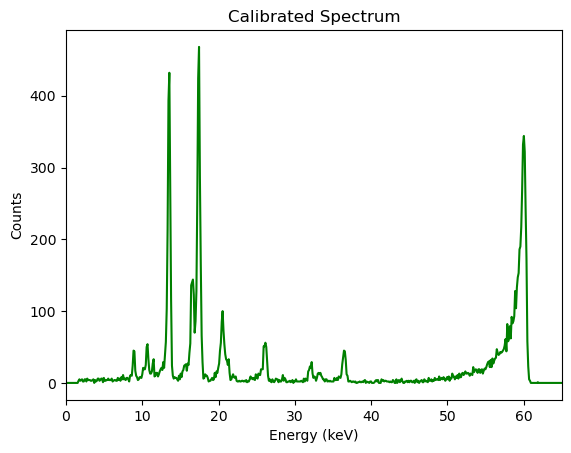

In [16]:
plt.figure()
plt.plot(energy_axis, cal_spec.counts, color ='green')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title("Calibrated Spectrum")
plt.xlim(0, 65)
plt.show()

## 50 degree

#### Data

In [17]:
# data
deg50_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021926_labhours_50deg_Gain5.26_2048ch.mca"
)
print("channels:", deg50_spec.counts.size)
print("live time:", deg50_spec.header.get("LIVE_TIME"))
print("start time:", deg50_spec.header.get("START_TIME"))
print("n rois:", len(deg50_spec.rois))
print("cal points:", deg50_spec.calibration_points[:5])


channels: 2048
live time: 5633.924922
start time: 02/19/2026 15:00:28
n rois: 0
cal points: [(125.51, 13.5), (527.84, 59.54)]


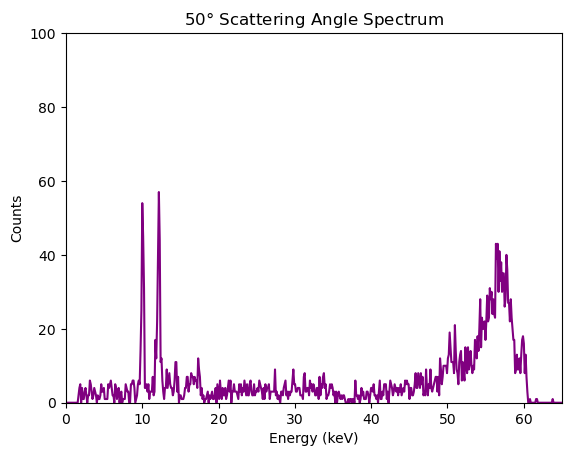

In [122]:
plt.figure()
plt.plot(energy_axis, deg50_spec.counts, color ='purple')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title(f"50$\degree$ Scattering Angle Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 100)
plt.show()

#### Background

In [19]:
# background 

deg50bk_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021926_labhours_50degbkgrnd_Gain5.26_2048ch.mca"
)
print("channels:", deg50bk_spec.counts.size)
print("live time:", deg50bk_spec.header.get("LIVE_TIME"))
print("start time:", deg50bk_spec.header.get("START_TIME"))
print("n rois:", len(deg50bk_spec.rois))
print("cal points:", deg50bk_spec.calibration_points[:5])

channels: 2048
live time: 2725.391503
start time: 02/19/2026 13:24:39
n rois: 0
cal points: [(125.51, 13.5), (527.84, 59.54)]


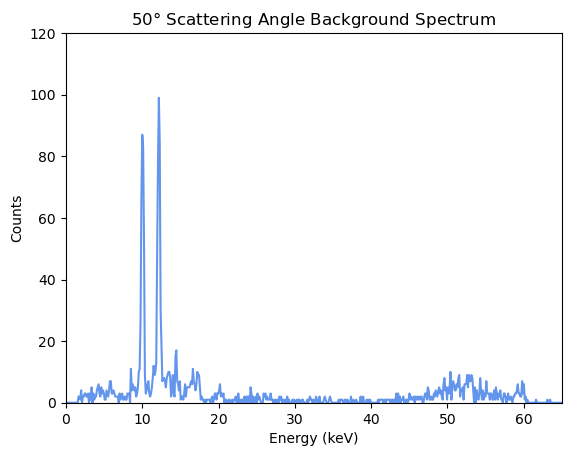

In [121]:
plt.figure()
plt.plot(energy_axis, deg50bk_spec.counts, color ='cornflowerblue')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title(f"50$\degree$ Scattering Angle Background Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 120)
plt.show()

In [142]:
# scaling bkgrnd
scale_50 = float(deg50_spec.header.get("LIVE_TIME")) / float(deg50bk_spec.header.get("LIVE_TIME"))

counts_deg50 = deg50_spec.counts
counts_deg50bk_scaled = scale_50 * deg50bk_spec.counts
counts_50 = counts_deg50 - counts_deg50bk_scaled

#### Setting up integration

In [143]:
# integrating over set fraction of peak

E = energy_axis      

peaks_50, props_50 = find_peaks(counts_50, prominence=20)  

target_keV = 60.0
band = 12.0 

in_band = [p for p in peaks_50 if (target_keV - band) <= E[p] <= (target_keV + band)]
if not in_band:
    raise ValueError("No peaks found near 60 keV. Lower prominence or widen the band.")

peak_idx = max(in_band, key=lambda p: counts_50[p])

print("Using peak at", E[peak_idx], "keV with height", counts_50[peak_idx])


Using peak at 56.58304029030894 keV with height 40.9328016118791


In [144]:
half_window_keV = 10
win = (E >= E[peak_idx] - half_window_keV) & (E <= E[peak_idx] + half_window_keV)

Ew_50 = E[win]
cw_50 = counts_50[win]

In [145]:
total_area = cw_50.sum()
target_area = 0.75 * total_area

center = int(np.argmax(cw_50)) 
left = right = center
area = cw_50[center]

while area < target_area and (left > 0 or right < len(cw_50) - 1):
    add_left  = cw_50[left - 1]  if left > 0 else -1
    add_right = cw_50[right + 1] if right < len(cw_50) - 1 else -1

    if add_right >= add_left:
        right += 1
    else:
        left -= 1

    area += (add_right if add_right >= add_left else add_left)

Emin_50, Emax_50 = Ew_50[left], Ew_50[right]
area50 = cw_50[left:right+1].sum()

print(f"75% area window: {Emin_50:.2f} to {Emax_50:.2f} keV")
print("75% area (counts):", area50)

75% area window: 55.21 to 58.64 keV
75% area (counts): 794.833699936504


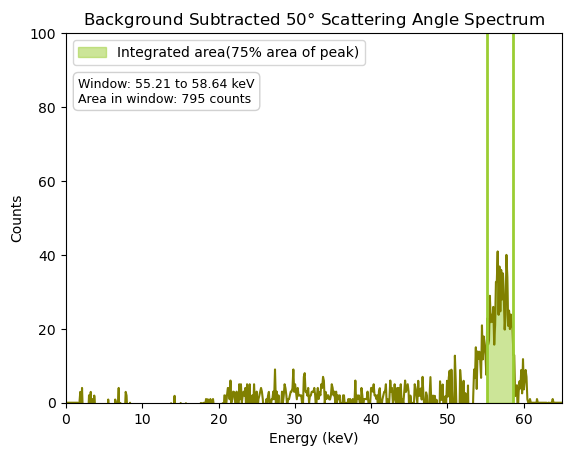

In [146]:
area_show = True  # False to get rid of visual integration

plt.figure()
plt.plot(E, counts_50, color='olive')
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title(f"Background Subtracted 50$\degree$ Scattering Angle Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 100)

if area_show:
    plt.axvline(Emin_50, color='yellowgreen', linewidth=2, label="75% window bounds")
    plt.axvline(Emax_50, color='yellowgreen', linewidth=2)
    plt.fill_between(Ew_50[left:right+1], cw_50[left:right+1],
                     alpha=0.5, color='yellowgreen')

    total_area = cw_50.sum()
    frac = area50 / total_area if total_area != 0 else np.nan

    note = (
        f"Window: {Emin_50:.2f} to {Emax_50:.2f} keV\n"
        f"Area in window: {area50:.0f} counts"
    )

    ax = plt.gca()
    ax.text(
        0.025, 0.88, note,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9, edgecolor="0.8")
    )
    pink_patch = mpatches.Patch(color='yellowgreen', alpha=0.5, label='Integrated area(75% area of peak)')
    ax.legend(fontsize = 'medium', handles=[pink_patch], loc="upper left")

plt.show()

## 65 degree

#### Data

In [26]:
# data
deg65_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021826_overnight_65deg_Gain5.26_2048ch.mca"
)
print("channels:", deg65_spec.counts.size)
print("live time:", deg65_spec.header.get("LIVE_TIME"))
print("start time:", deg65_spec.header.get("START_TIME"))
print("n rois:", len(deg65_spec.rois))
print("cal points:", deg65_spec.calibration_points[:5])


channels: 2048
live time: 74523.325000
start time: 02/18/2026 13:20:42
n rois: 0
cal points: [(125.51, 13.5), (527.84, 59.54)]


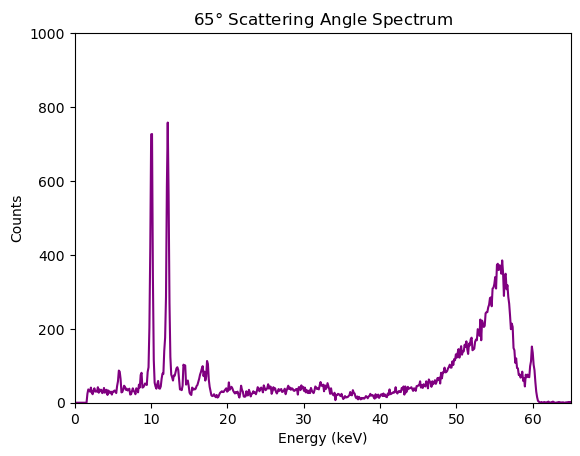

In [126]:
plt.figure()
plt.plot(energy_axis, deg65_spec.counts, color ='purple')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title(f"65$\degree$ Scattering Angle Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 1000)
plt.show()

#### Background

In [152]:
# background 

deg65bk_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021726_labhours_65degbkgrnd_Gain5.26_2048ch.mca"
)
print("channels:", deg65bk_spec.counts.size)
print("live time:", deg65bk_spec.header.get("LIVE_TIME"))
print("start time:", deg65bk_spec.header.get("START_TIME"))
print("n rois:", len(deg65bk_spec.rois))
print("cal points:", deg65bk_spec.calibration_points[:5])

channels: 2048
live time: 4695.326179
start time: 02/17/2026 14:56:42
n rois: 4
cal points: [(125.51, 13.5), (527.84, 59.54)]


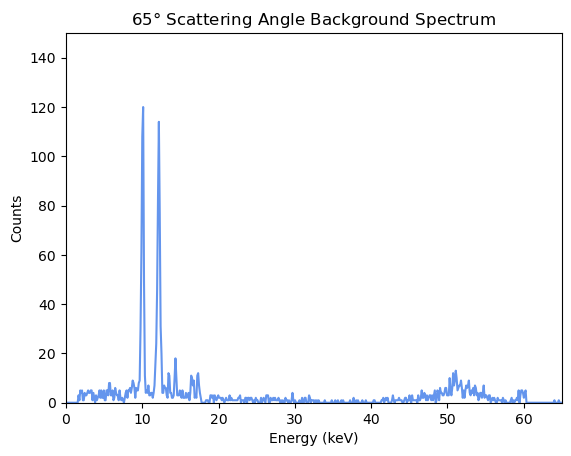

In [153]:
plt.figure()
plt.plot(energy_axis, deg65bk_spec.counts, color ='cornflowerblue')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title(f"65$\degree$ Scattering Angle Background Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 150)
plt.show()

In [154]:
# scaling bkgrnd
scale_65 = float(deg65_spec.header.get("LIVE_TIME")) / float(deg65bk_spec.header.get("LIVE_TIME"))

counts_deg65 = deg65_spec.counts
counts_deg65bk_scaled = scale_65 * deg65bk_spec.counts
counts_65 = counts_deg65 - counts_deg65bk_scaled

#### Setting up integration

In [155]:
# integrating over set fraction of peak

E = energy_axis      

peaks_65, props_65 = find_peaks(counts_65, prominence=20)  

target_keV = 60.0
band = 12.0 

in_band = [p for p in peaks_65 if (target_keV - band) <= E[p] <= (target_keV + band)]
if not in_band:
    raise ValueError("No peaks found near 60 keV. Lower prominence or widen the band.")

peak_idx = max(in_band, key=lambda p: counts_65[p])

print("Using peak at", E[peak_idx], "keV with height", counts_65[peak_idx])


Using peak at 55.66757288792781 keV with height 372.0


In [156]:
half_window_keV = 10
win = (E >= E[peak_idx] - half_window_keV) & (E <= E[peak_idx] + half_window_keV)

Ew_65 = E[win]
cw_65 = counts_65[win]

In [157]:
total_area = cw_65.sum()
target_area = 0.75 * total_area

center = int(np.argmax(cw_65)) 
left = right = center
area = cw_65[center]

while area < target_area and (left > 0 or right < len(cw_65) - 1):
    add_left  = cw_65[left - 1]  if left > 0 else -1
    add_right = cw_65[right + 1] if right < len(cw_65) - 1 else -1

    if add_right >= add_left:
        right += 1
    else:
        left -= 1

    area += (add_right if add_right >= add_left else add_left)

Emin_65, Emax_65 = Ew_65[left], Ew_65[right]
area65 = cw_65[left:right+1].sum()

print(f"75% area window: {Emin_65:.2f} to {Emax_65:.2f} keV")
print("75% area (counts):", area65)

75% area window: 52.92 to 58.07 keV
75% area (counts): 10308.203570024438


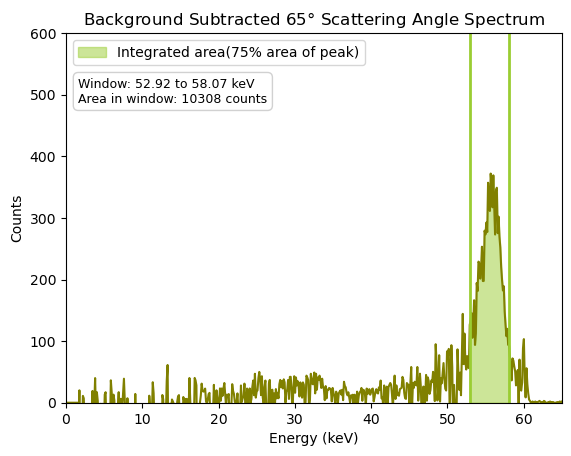

In [159]:
area_show = True  # False to get rid of visual integration

plt.figure()
plt.plot(E, counts_65, color='olive')
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title(f"Background Subtracted 65$\degree$ Scattering Angle Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 600)

if area_show:
    plt.axvline(Emin_65, color='yellowgreen', linewidth=2, label="75% window bounds")
    plt.axvline(Emax_65, color='yellowgreen', linewidth=2)
    plt.fill_between(Ew_65[left:right+1], cw_65[left:right+1],
                     alpha=0.5, color='yellowgreen')

    total_area = cw_65.sum()
    frac = area65 / total_area if total_area != 0 else np.nan

    note = (
        f"Window: {Emin_65:.2f} to {Emax_65:.2f} keV\n"
        f"Area in window: {area65:.0f} counts"
    )

    ax = plt.gca()
    ax.text(
        0.025, 0.88, note,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9, edgecolor="0.8")
    )
    pink_patch = mpatches.Patch(color='yellowgreen', alpha=0.5, label='Integrated area(75% area of peak)')
    ax.legend(fontsize = 'medium', handles=[pink_patch], loc="upper left")

plt.show()

## 80 degree

#### Data

In [35]:
deg80_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021226_overnight_80deg_Gain5.26_2048ch.mca"
)
print("channels:", deg80_spec.counts.size)
print("live time:", deg80_spec.header.get("LIVE_TIME"))
print("start time:", deg80_spec.header.get("START_TIME"))
print("n rois:", len(deg80_spec.rois))
print("cal points:", deg80_spec.calibration_points[:5])

channels: 2048
live time: 72445.203000
start time: 02/11/2026 16:55:00
n rois: 2
cal points: [(503.91, 13.5), (2116.36, 59.54)]


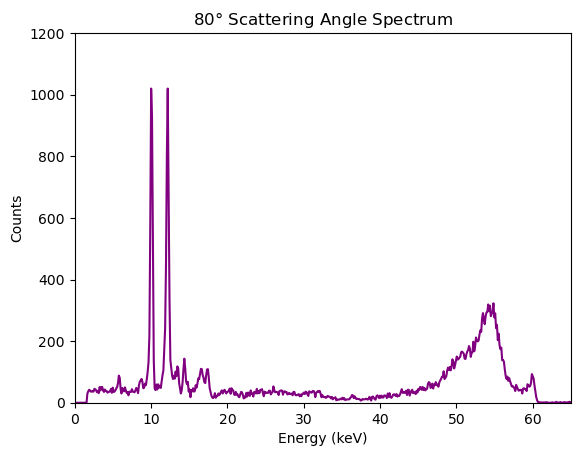

In [128]:
plt.figure()
plt.plot(energy_axis, deg80_spec.counts, color ='purple')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title(f"80$\degree$ Scattering Angle Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 1200)
plt.show()

#### Background

In [37]:
# background 

deg80bk_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021226_labhours_80degbkgrnd_Gain5.26_2048ch.mca"
)
print("channels:", deg80bk_spec.counts.size)
print("live time:", deg80bk_spec.header.get("LIVE_TIME"))
print("start time:", deg80bk_spec.header.get("START_TIME"))
print("n rois:", len(deg80bk_spec.rois))
print("cal points:", deg80bk_spec.calibration_points[:5])


channels: 2048
live time: 5867.798859
start time: 02/12/2026 13:50:31
n rois: 2
cal points: [(125.51, 13.5), (527.84, 59.54)]


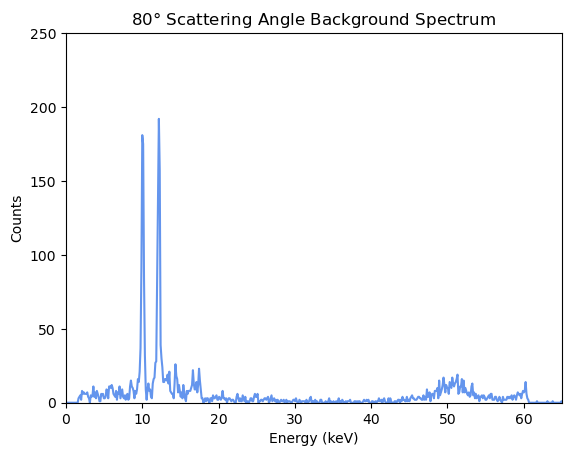

In [129]:
plt.figure()
plt.plot(energy_axis, deg80bk_spec.counts, color ='cornflowerblue')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title(f"80$\degree$ Scattering Angle Background Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 250)
plt.show()

In [39]:
# scaling bkgrnd
scale_80 = float(deg80_spec.header.get("LIVE_TIME")) / float(deg80bk_spec.header.get("LIVE_TIME"))

counts_deg80 = deg80_spec.counts
counts_deg80bk_scaled = scale_80 * deg80bk_spec.counts
counts_80 = counts_deg80 - counts_deg80bk_scaled

#### Setting up integration

In [40]:
# integrating over set fraction of peak

E = energy_axis      

peaks_80, props_80 = find_peaks(counts_80, prominence=20)  

target_keV = 60.0
band = 12.0 

in_band = [p for p in peaks_80 if (target_keV - band) <= E[p] <= (target_keV + band)]
if not in_band:
    raise ValueError("No peaks found near 60 keV. Lower prominence or widen the band.")

peak_idx = max(in_band, key=lambda p: counts_80[p])

print("Using peak at", E[peak_idx], "keV with height", counts_80[peak_idx])


Using peak at 54.179938359058475 keV with height 306.6537685185163


In [41]:
half_window_keV = 10
win = (E >= E[peak_idx] - half_window_keV) & (E <= E[peak_idx] + half_window_keV)

Ew_80 = E[win]
cw_80 = counts_80[win]

In [161]:
total_area = cw_80.sum()
target_area = 0.75 * total_area

center = int(np.argmax(cw_80)) 
left = right = center
area = cw_80[center]

while area < target_area and (left > 0 or right < len(cw_80) - 1):
    add_left  = cw_80[left - 1]  if left > 0 else -1
    add_right = cw_80[right + 1] if right < len(cw_80) - 1 else -1

    if add_right >= add_left:
        right += 1
    else:
        left -= 1

    area += (add_right if add_right >= add_left else add_left)

Emin_80, Emax_80 = Ew_80[left], Ew_80[right]
area80 = cw_80[left:right+1].sum()

print(f"75% area window: {Emin_80:.2f} to {Emax_80:.2f} keV")
print("75% area (counts):", area80)


75% area window: 53.26 to 56.24 keV
75% area (counts): 5350.875842592341


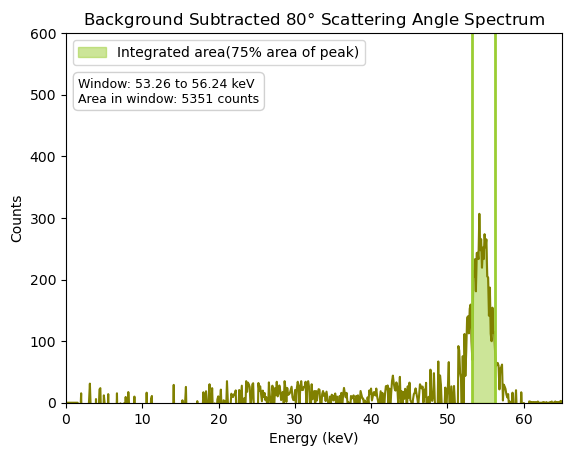

In [162]:
area_show = True  # False to get rid of visual integration

plt.figure()
plt.plot(E, counts_80, color='olive')
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title(f"Background Subtracted 80$\degree$ Scattering Angle Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 600)

if area_show:
    plt.axvline(Emin_80, color='yellowgreen', linewidth=2, label="75% window bounds")
    plt.axvline(Emax_80, color='yellowgreen', linewidth=2)
    plt.fill_between(Ew_80[left:right+1], cw_80[left:right+1],
                     alpha=0.5, color='yellowgreen')

    total_area = cw_80.sum()
    frac = area80 / total_area if total_area != 0 else np.nan

    note = (
        f"Window: {Emin_80:.2f} to {Emax_80:.2f} keV\n"
        f"Area in window: {area80:.0f} counts"
    )

    ax = plt.gca()
    ax.text(
        0.025, 0.88, note,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9, edgecolor="0.8")
    )
    pink_patch = mpatches.Patch(color='yellowgreen', alpha=0.5, label='Integrated area(75% area of peak)')
    ax.legend(fontsize = 'medium', handles=[pink_patch], loc="upper left")

plt.show()

## 95 degree

#### Data

In [ ]:
# data
deg95_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021926_overnight_95deg_Gain5.26_2048ch.mca"
)
print("channels:", deg95_spec.counts.size)
print("live time:", deg95_spec.header.get("LIVE_TIME"))
print("start time:", deg95_spec.header.get("START_TIME"))
print("n rois:", len(deg95_spec.rois))
print("cal points:", deg95_spec.calibration_points[:5])

In [ ]:
plt.figure()
plt.plot(energy_axis, deg95_spec.counts, color ='purple')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title("95 Degree Scattering Angle Spectrum")
plt.xlim(0, 65)
plt.ylim(0, np.max(deg95_spec.counts) + 100)
plt.show()

#### Background

In [ ]:
# background 

deg95bk_spec = read_amptek_mca(
    r"")
print("channels:", deg95bk_spec.counts.size)
print("live time:", deg95bk_spec.header.get("LIVE_TIME"))
print("start time:", deg95bk_spec.header.get("START_TIME"))
print("n rois:", len(deg95bk_spec.rois))
print("cal points:", deg95bk_spec.calibration_points[:5])


In [ ]:
plt.figure()
plt.plot(energy_axis, deg95bk_spec.counts, color ='cornflowerblue')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title(f"95$\degree$ Scattering Angle Background Spectrum")
plt.xlim(0, 65)
plt.ylim(0, np.max(deg95bk_spec.counts) + 100)
plt.show()

In [ ]:
# scaling bkgrnd
scale_95 = float(deg95_spec.header.get("LIVE_TIME")) / float(deg95bk_spec.header.get("LIVE_TIME"))

counts_deg95 = deg95_spec.counts
counts_deg95bk_scaled = scale_95 * deg95bk_spec.counts
counts_95 = counts_deg95 - counts_deg95bk_scaled

#### Setting up the integration

In [ ]:
# integrating over set fraction of peak

E = energy_axis      

peaks_95, props_95 = find_peaks(counts_95, prominence=20)  

target_keV = 60.0
band = 12.0 

in_band = [p for p in peaks_95 if (target_keV - band) <= E[p] <= (target_keV + band)]
if not in_band:
    raise ValueError("No peaks found near 60 keV. Lower prominence or widen the band.")

peak_idx = max(in_band, key=lambda p: counts_95[p])

print("Using peak at", E[peak_idx], "keV with height", counts_95[peak_idx])


In [ ]:
half_window_keV = 10
win = (E >= E[peak_idx] - half_window_keV) & (E <= E[peak_idx] + half_window_keV)

Ew_95 = E[win]
cw_95 = counts_95[win]

In [ ]:
total_area = cw_95.sum()
target_area = 0.75 * total_area

center = int(np.argmax(cw_95)) 
left = right = center
area = cw_95[center]

while area < target_area and (left > 0 or right < len(cw_95) - 1):
    add_left  = cw_95[left - 1]  if left > 0 else -1
    add_right = cw_95[right + 1] if right < len(cw_95) - 1 else -1

    if add_right >= add_left:
        right += 1
    else:
        left -= 1

    area += (add_right if add_right >= add_left else add_left)

Emin_95, Emax_95 = Ew_95[left], Ew_95[right]
area95 = cw_95[left:right+1].sum()

print(f"75% area window: {Emin_95:.2f} to {Emax_95:.2f} keV")
print("75% area (counts):", area95)


In [ ]:
area_show = True  # False to get rid of visual integration

plt.figure()
plt.plot(E, counts_65, color='olive')
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title(f"Background Subtracted 95$\degree$ Scattering Angle Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 600)

if area_show:
    plt.axvline(Emin_95, color='yellowgreen', linewidth=2, label="75% window bounds")
    plt.axvline(Emax_95, color='yellowgreen', linewidth=2)
    plt.fill_between(Ew_95[left:right+1], cw_95[left:right+1],
                     alpha=0.5, color='yellowgreen')

    total_area = cw_95.sum()
    frac = area95 / total_area if total_area != 0 else np.nan

    note = (
        f"Window: {Emin_95:.2f} to {Emax_95:.2f} keV\n"
        f"Area in window: {area95:.0f} counts"
    )

    ax = plt.gca()
    ax.text(
        0.025, 0.88, note,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9, edgecolor="0.8")
    )
    pink_patch = mpatches.Patch(color='yellowgreen', alpha=0.5, label='Integrated area(75% area of peak)')
    ax.legend(fontsize = 'medium', handles=[pink_patch], loc="upper left")

plt.show()

## 110 degree

#### Data

In [44]:
# data
deg110_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021326_overnight_110deg_Gain5.26_2048ch.mca"
)
print("channels:", deg110_spec.counts.size)
print("live time:", deg110_spec.header.get("LIVE_TIME"))
print("start time:", deg110_spec.header.get("START_TIME"))
print("n rois:", len(deg110_spec.rois))
print("cal points:", deg110_spec.calibration_points[:5])


channels: 2048
live time: 74822.406000
start time: 02/12/2026 16:30:39
n rois: 2
cal points: [(125.51, 13.5), (527.84, 59.54)]


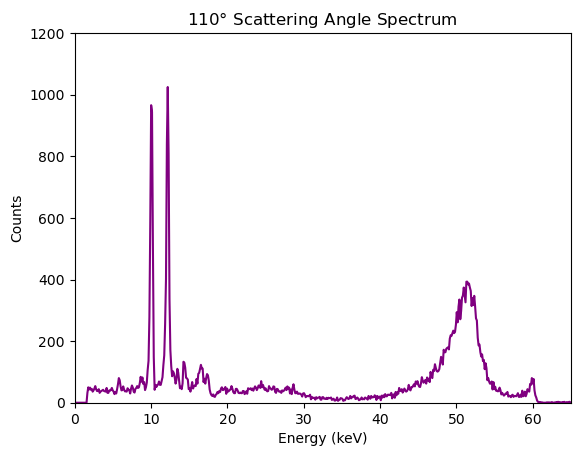

In [130]:
plt.figure()
plt.plot(energy_axis, deg110_spec.counts, color ='purple')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title(f"110$\degree$ Scattering Angle Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 1200)
plt.show()

#### Background

In [46]:
# background 

deg110bk_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021326_labhours_110degbkgrnd_Gain5.26_2048ch.mca"
)
print("channels:", deg110bk_spec.counts.size)
print("live time:", deg110bk_spec.header.get("LIVE_TIME"))
print("start time:", deg110bk_spec.header.get("START_TIME"))
print("n rois:", len(deg110bk_spec.rois))
print("cal points:", deg110bk_spec.calibration_points[:5])


channels: 2048
live time: 11014.511000
start time: 02/13/2026 14:30:29
n rois: 1
cal points: [(125.51, 13.5), (527.84, 59.54)]


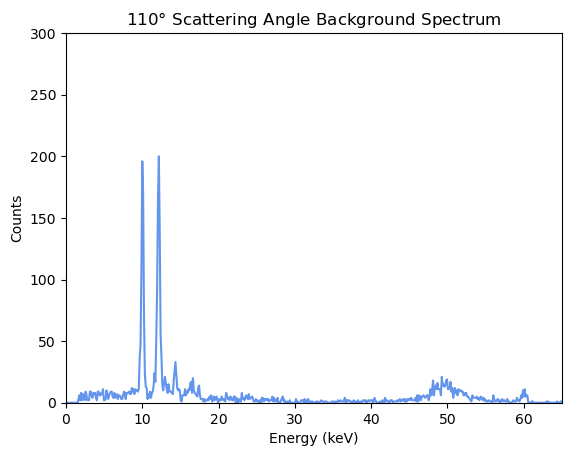

In [131]:
plt.figure()
plt.plot(energy_axis, deg110bk_spec.counts, color ='cornflowerblue')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title(f"110$\degree$ Scattering Angle Background Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 300)
plt.show()

In [48]:
# scaling bkgrnd
scale_110 = float(deg110_spec.header.get("LIVE_TIME")) / float(deg110bk_spec.header.get("LIVE_TIME"))

counts_deg110 = deg110_spec.counts
counts_deg110bk_scaled = scale_110 * deg110bk_spec.counts
counts_110 = counts_deg110 - counts_deg110bk_scaled

#### Setting up integration

In [49]:
# integrating over set fraction of peak

E = energy_axis      

peaks_110, props_110 = find_peaks(counts_110, prominence=20)  

target_keV = 60.0
band = 12.0 

in_band = [p for p in peaks_110 if (target_keV - band) <= E[p] <= (target_keV + band)]
if not in_band:
    raise ValueError("No peaks found near 60 keV. Lower prominence or widen the band.")

peak_idx = max(in_band, key=lambda p: counts_110[p])

print("Using peak at", E[peak_idx], "keV with height", counts_110[peak_idx])


Using peak at 51.319102726617444 keV with height 352.24154635643833


In [50]:
half_window_keV = 10
win = (E >= E[peak_idx] - half_window_keV) & (E <= E[peak_idx] + half_window_keV)

Ew_110 = E[win]
cw_110 = counts_110[win]

In [163]:
total_area = cw_110.sum()
target_area = 0.75 * total_area

center = int(np.argmax(cw_110)) 
left = right = center
area = cw_110[center]

while area < target_area and (left > 0 or right < len(cw_110) - 1):
    add_left  = cw_110[left - 1]  if left > 0 else -1
    add_right = cw_110[right + 1] if right < len(cw_110) - 1 else -1

    if add_right >= add_left:
        right += 1
    else:
        left -= 1

    area += (add_right if add_right >= add_left else add_left)

Emin_110, Emax_110 = Ew_110[left], Ew_110[right]
area110 = cw_110[left:right+1].sum()

print(f"75% area window: {Emin_110:.2f} to {Emax_110:.2f} keV")
print("75% area (counts):", area110)


75% area window: 47.89 to 54.64 keV
75% area (counts): 10092.807608617397


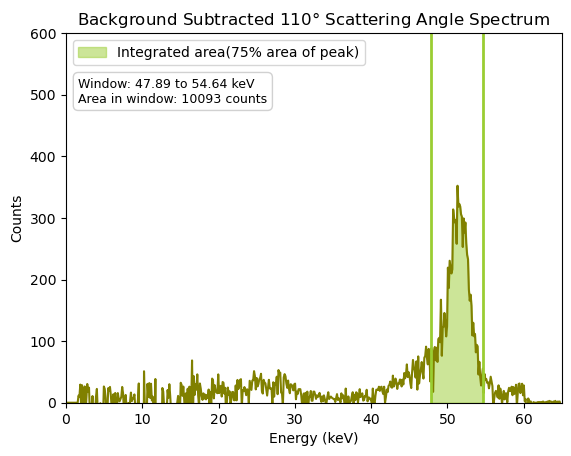

In [165]:
area_show = True  # False to get rid of visual integration

plt.figure()
plt.plot(E, counts_110, color='olive')
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title(f"Background Subtracted 110$\degree$ Scattering Angle Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 600)

if area_show:
    plt.axvline(Emin_110, color='yellowgreen', linewidth=2, label="75% window bounds")
    plt.axvline(Emax_110, color='yellowgreen', linewidth=2)
    plt.fill_between(Ew_110[left:right+1], cw_110[left:right+1],
                     alpha=0.5, color='yellowgreen')

    total_area = cw_110.sum()
    frac = area110 / total_area if total_area != 0 else np.nan

    note = (
        f"Window: {Emin_110:.2f} to {Emax_110:.2f} keV\n"
        f"Area in window: {area110:.0f} counts"
    )

    ax = plt.gca()
    ax.text(
        0.025, 0.88, note,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9, edgecolor="0.8")
    )
    pink_patch = mpatches.Patch(color='yellowgreen', alpha=0.5, label='Integrated area(75% area of peak)')
    ax.legend(fontsize = 'medium', handles=[pink_patch], loc="upper left")

plt.show()

## Compton Continuum

In [53]:
# data
cc_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021726_wkndrun_comptoncont_Gain5.26_2048ch.mca"
)
print("channels:", cc_spec.counts.size)
print("live time:", cc_spec.header.get("LIVE_TIME"))
print("start time:", cc_spec.header.get("START_TIME"))
print("n rois:", len(cc_spec.rois))
print("cal points:", cc_spec.calibration_points[:5])


channels: 2048
live time: 332374.133000
start time: 02/13/2026 16:41:38
n rois: 1
cal points: [(125.51, 13.5), (527.84, 59.54)]


C:\Users\kaela\AppData\Local\Temp\ipykernel_20068\3262389845.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


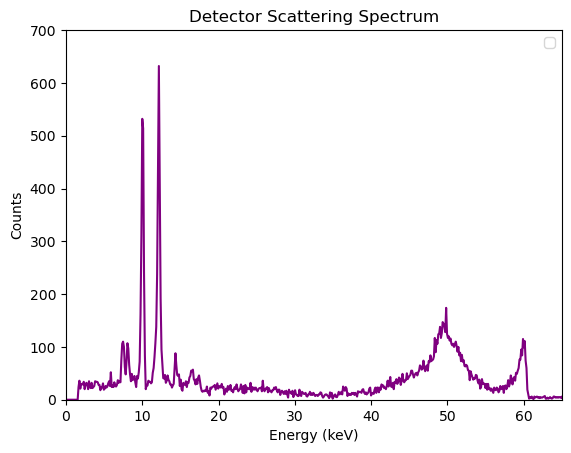

In [54]:
plt.figure()
plt.plot(energy_axis, cc_spec.counts, color ='purple')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title("Detector Scattering Spectrum")
plt.xlim(0, 65)
plt.ylim(0, 700)
plt.legend()
plt.show()

## Klein-Nishina

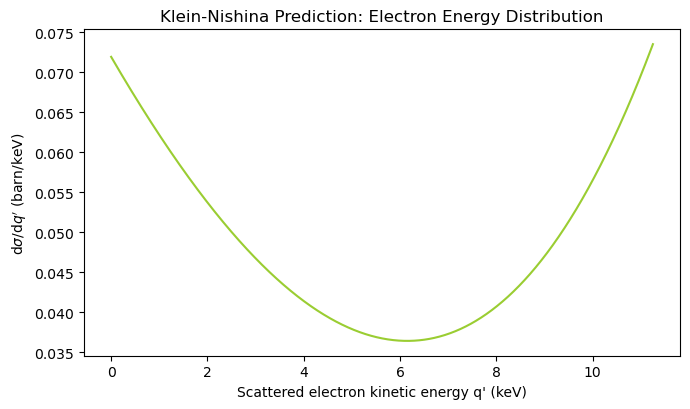

In [55]:
## theoretical klein-nishina

E0_keV = 59.54
mec2_keV = 511.0
r0_m = 2.8179403262e-15
barn_m2 = 1e-28

theta_deg = np.linspace(0.001, 180.0, 2000)   
theta = np.deg2rad(theta_deg)

alpha = E0_keV / mec2_keV

# KN 
f = 1 + np.cos(theta)**2
g = alpha * (1 - np.cos(theta))

dsdo_m2 = (r0_m**2 / 2) * (1 / (1 + g)**2) * (f + (g**2 / (1 + g)))
dsdo_barn = dsdo_m2 / barn_m2  

kprime_keV = E0_keV / (1 + alpha * (1 - np.cos(theta)))
qprime_keV = E0_keV - kprime_keV

dsdq_barn_per_keV = dsdo_barn * (2*np.pi*mec2_keV) / (kprime_keV**2)

order = np.argsort(qprime_keV)
q_sorted = qprime_keV[order]
dsdq_sorted = dsdq_barn_per_keV[order]

plt.figure(figsize=(7,4.2))
plt.plot(q_sorted, dsdq_sorted, color = 'yellowgreen')
plt.xlabel("Scattered electron kinetic energy q' (keV)")
plt.ylabel(r"d$\sigma$/d$q'$ (barn/keV)")
plt.title("Klein-Nishina Prediction: Electron Energy Distribution")
plt.tight_layout()
plt.show()

#### KN considering discrete scattering angles

In [56]:
detector_width_mm = 3.0
detector_height_mm = 3.0
A_det_mm2 = detector_width_mm * detector_height_mm  

dst = 225.0 # source -> target (mm)
dtd = 40.0 # target -> detector (mm)

data = {
    50:  {'counts': area50, 'live_time': float(deg50_spec.header.get("LIVE_TIME"))},
    65:  {'counts': area65, 'live_time': float(deg65_spec.header.get("LIVE_TIME"))},
    80:  {'counts': area80, 'live_time': float(deg80_spec.header.get("LIVE_TIME"))},
    #95:  {'counts': None, 'live_time': None},
    110: {'counts': area110, 'live_time': float(deg110_spec.header.get("LIVE_TIME"))}, 
}

def geometry_dsd(dst_mm, dtd_mm, theta_deg):
    phi_rad = np.deg2rad(180.0 - theta_deg)
    dsd = np.sqrt(dst_mm**2 + dtd_mm**2 - 2.0 * dst_mm * dtd_mm * np.cos(phi_rad))
    return dsd

results = []
for theta_deg, meas in sorted(data.items()):
    dsd = geometry_dsd(dst, dtd, theta_deg)  # mm
    if meas.get('counts') is not None and meas.get('live_time') not in (None, 0):
        R = meas['counts'] / meas['live_time']
    else:
        R = None

    if R is not None:
        det_per_mm2 = R / A_det_mm2                        

        source_per_mm2 = det_per_mm2 * (dsd / dst)**2   
    else:
        det_per_mm2 = None
        source_per_mm2 = None

    results.append({
        'theta_deg': theta_deg,
        'dsd_mm': dsd,
        'R_cps': R,
        'det_cps_per_mm2': det_per_mm2,
        'source_cps_per_mm2': source_per_mm2
    })

print(f"Detector area = {A_det_mm2:.3f} mm^2, dst = {dst} mm, dtd = {dtd} mm\n")
print(f"{'theta (deg)':>10} | {'dsd (mm)':>9} | {'R (cps)':>9} | {'det (cps/mm2)':>15} | {'source (cps/mm2)':>17}")
print("-"*70)
for r in results:
    theta = r['theta_deg']
    dsd = r['dsd_mm']
    R = r['R_cps']
    det_mm2 = r['det_cps_per_mm2']
    src_mm2 = r['source_cps_per_mm2']
    print(f"{theta:10.1f} | {dsd:9.1f} | {R if R is None else f'{R:9.6f}'} | "
          f"{det_mm2 if det_mm2 is None else f'{det_mm2:15.6e}'} | "
          f"{src_mm2 if src_mm2 is None else f'{src_mm2:17.6e}'}")

Detector area = 9.000 mm^2, dst = 225.0 mm, dtd = 40.0 mm

theta (deg) |  dsd (mm) |   R (cps) |   det (cps/mm2) |  source (cps/mm2)
----------------------------------------------------------------------
      50.0 |     252.6 |  0.141080 |    1.567555e-02 |      1.975357e-02
      65.0 |     244.6 |  0.138322 |    1.536909e-02 |      1.816426e-02
      80.0 |     235.3 |  0.073861 |    8.206779e-03 |      8.972853e-03
     110.0 |     214.6 |  0.134890 |    1.498780e-02 |      1.363886e-02


ΔΩ = 5.6250e-03 sr   (A_det=0.0900 cm^2, r=4.0 cm)
N_e = 1.3339e+25 electrons

theta | area(counts) | live(s) | R(cps) ± unc | dσ/dΩ (barn/sr) ± unc
-------------------------------------------------------------------------------------
   50 |       794.8 |  5633.9 | 0.141080 ± 0.005004 | 9.518565e-25 ± 3.208580e-25
   65 |     10308.2 | 74523.3 | 0.138322 ± 0.001362 | 1.014904e-24 ± 3.385965e-25
   80 |      5350.9 | 72445.2 | 0.073861 ± 0.001010 | 1.097075e-24 ± 3.663064e-25
  110 |     10092.8 | 74822.4 | 0.134890 ± 0.001343 | 1.318117e-24 ± 4.397640e-25


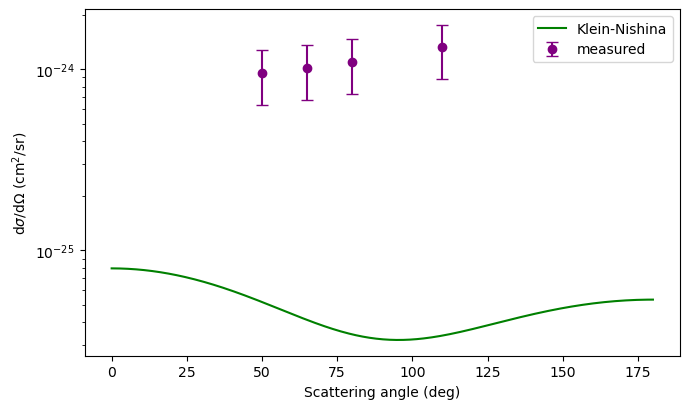

In [166]:
areas = {
    50: area50,
    65: area65,
    80: area80,
    110: area110,
}

spec_objs = {
    50: deg50_spec,
    65: deg65_spec,
    80: deg80_spec,
    110: deg110_spec,
}

A_det_mm2 = 9.0
A_det_cm2 = A_det_mm2 / 100.0  

# distance for solid angle 
r_cm = 40.0 / 10.0 # dist from center of target to detector in cm
DeltaOmega = A_det_cm2 / (r_cm**2)
dst = 225.0 # mm
dtd = 40.0 # mm

N_A = 6e23
density_Al = 2.7   
A_Al = 27.0
Z_Al = 13.0
d_cm = 1.905 # diameter of target
h_cm = 6 # heigh of target intercepted by beam -> remember this data did not have collimator
h_unc_cm = 2.0     

vol_cm3 = np.pi * (d_cm/2.0)**2 * h_cm
mass_g = density_Al * vol_cm3
atoms = (mass_g / A_Al) * N_A
N_e = atoms * Z_Al

print(f"ΔΩ = {DeltaOmega:.4e} sr   (A_det={A_det_cm2:.4f} cm^2, r={r_cm} cm)")
print(f"N_e = {N_e:.4e} electrons\n")

rows = []
for theta_deg in sorted(areas.keys()):
    area_counts = float(areas[theta_deg])
    live_time = float(spec_objs[theta_deg].header.get("LIVE_TIME"))

    # measured rate and Poisson uncertainty
    R_cps = area_counts / live_time
    R_unc = np.sqrt(area_counts) / live_time

    # detector-normalized rate 
    det_per_mm2 = R_cps / A_det_mm2
    det_unc_per_mm2 = R_unc / A_det_mm2

    # back-project to source plane 
    dsd_mm = geometry_dsd(dst, dtd, theta_deg)
    source_per_mm2 = det_per_mm2 * (dsd_mm / dst)**2
    source_unc_per_mm2 = det_unc_per_mm2 * (dsd_mm / dst)**2

    # flux at target 
    phi_per_cm2_s = source_per_mm2 * 100.0
    phi_unc_per_cm2_s = source_unc_per_mm2 * 100.0

    dsdo_cm2_per_sr = R_cps / (phi_per_cm2_s * N_e * DeltaOmega)

    # uncertainty propagation 
    rel_var = 0.0
    if R_cps > 0:
        rel_var += (R_unc / R_cps)**2
    if phi_per_cm2_s > 0:
        rel_var += (phi_unc_per_cm2_s / phi_per_cm2_s)**2
    rel_var += (h_unc_cm / h_cm)**2

    dsdo_unc_cm2 = dsdo_cm2_per_sr * np.sqrt(rel_var)

    rows.append((theta_deg, area_counts, live_time, R_cps, R_unc, dsdo_cm2_per_sr, dsdo_unc_cm2))

print(r"theta | area(counts) | live(s) | R(cps) ± unc | dσ/dΩ (barn/sr) ± unc")
print("-"*85)
for th, area_c, t, R, Ru, ds, dsu in rows:
    print(f"{th:5.0f} | {area_c:11.1f} | {t:7.1f} | {R:8.6f} ± {Ru:8.6f} | {ds:10.6e} ± {dsu:10.6e}")

E0_keV = 59.54
mec2_keV = 511.0
r0_m = 2.8179403262e-15

theta_full_deg = np.linspace(0, 180, 400)
theta_full = np.deg2rad(theta_full_deg)

f = 1 + np.cos(theta_full)**2
g = (E0_keV / mec2_keV) * (1 - np.cos(theta_full))

dsdo_full_m2 = (r0_m**2 / 2.0) * (1.0 / (1.0 + g)**2) * (f + (g**2 / (1.0 + g)))
dsdo_full_cm2 = dsdo_full_m2 * 1e4   

theta_meas = [r[0] for r in rows]
dsdo_meas = [r[5] for r in rows]      
dsdo_meas_unc = [r[6] for r in rows]    

plt.figure(figsize=(7,4.2))
plt.plot(theta_full_deg, dsdo_full_cm2, label="Klein-Nishina", color='green')
plt.errorbar(theta_meas, dsdo_meas, yerr=dsdo_meas_unc, fmt="o",
             color="purple", label="measured", capsize=4)
plt.yscale("log")
plt.xlabel("Scattering angle (deg)")
plt.ylabel(r"d$\sigma$/d$\Omega$ (cm$^2$/sr)")
plt.legend()
plt.tight_layout()
plt.savefig("dsdo_measured_vs_KN_cm2sr.png", dpi=200)
plt.show()

C_kn = 2.98069e+24 ± 1.89e+22  (cps per (cm^2/sr))
chi2/dof = 1573.690/3


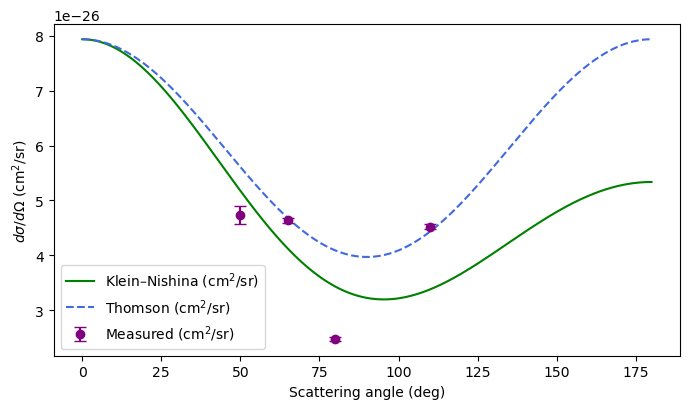

In [167]:
angles = np.array([50, 65, 80, 110], dtype=float)
R = np.array([0.141080, 0.138322, 0.073861, 0.134890], dtype=float)
R_unc = np.array([0.005004, 0.001362, 0.001010, 0.001343], dtype=float)

E0_keV = 59.54
mec2_keV = 511.0
r0_m = 2.8179403262e-15
r0_cm = r0_m * 100.0

def thomson_cm2(theta_deg):
    th = np.deg2rad(theta_deg)
    return (r0_cm**2 / 2.0) * (1.0 + np.cos(th)**2)  #

def klein_nishina_cm2(theta_deg):
    th = np.deg2rad(theta_deg)
    f = 1 + np.cos(th)**2
    g = (E0_keV/mec2_keV) * (1 - np.cos(th))
    return (r0_cm**2 / 2.0) * (1/(1+g)**2) * (f + (g**2/(1+g))) 

KN = np.array([klein_nishina_cm2(a) for a in angles])
TH = np.array([thomson_cm2(a) for a in angles])

# weighted least-squares scale factor
def fit_scale(model_vals, y, y_unc):
    w = 1.0 / (y_unc**2)
    C = np.sum(w * y * model_vals) / np.sum(w * model_vals * model_vals)
    C_unc = np.sqrt(1.0 / np.sum(w * model_vals * model_vals))
    chi2 = np.sum(((y - C*model_vals)/y_unc)**2)
    dof = len(y) - 1
    return C, C_unc, chi2, dof

C_kn, C_kn_unc, chi2_kn, dof_kn = fit_scale(KN, R, R_unc)

print(f"C_kn = {C_kn:.6g} ± {C_kn_unc:.3g}  (cps per (cm^2/sr))")
print(f"chi2/dof = {chi2_kn:.3f}/{dof_kn}")

dsdo_meas = R / C_kn
dsdo_meas_unc = R_unc / C_kn

theta_full = np.linspace(0, 180, 400)
KN_full = np.array([klein_nishina_cm2(t) for t in theta_full])
TH_full = np.array([thomson_cm2(t) for t in theta_full])

plt.figure(figsize=(7,4.2))

plt.errorbar(angles, dsdo_meas,
             yerr=dsdo_meas_unc,
             fmt='o', capsize=4,
             label="Measured (cm$^2$/sr)",
             color='purple')

plt.plot(theta_full, KN_full,
         label="Klein–Nishina (cm$^2$/sr)",
         color='green')

plt.plot(theta_full, TH_full,
         label="Thomson (cm$^2$/sr)",
         color='royalblue', linestyle='--')

plt.xlabel("Scattering angle (deg)")
plt.ylabel(r"$d\sigma/d\Omega$ (cm$^2$/sr)")
plt.legend()
plt.tight_layout()
plt.show()

ΔΩ = 5.6250e-03 sr   (A_det=0.0900 cm^2, r=4.00 cm)
N_e = 1.3397e+25 electrons   (Al rod, h = 6.0 ± 2.0 cm)

theta | dσ/dΩ (cm^2/sr) ± unc | R(cps) ± unc | phi (ph/s/cm^2)
--------------------------------------------------------------------------------------------
   50 |  9.477085e-25 ± 3.19e-25 |  0.141080 ± 0.005004 |  1.9754e+00
   65 |  1.010481e-24 ± 3.37e-25 |  0.138322 ± 0.001362 |  1.8164e+00
   80 |  1.092295e-24 ± 3.65e-25 |  0.073861 ± 0.001010 |  8.9729e-01
  110 |  1.312373e-24 ± 4.38e-25 |  0.134890 ± 0.001343 |  1.3639e+00


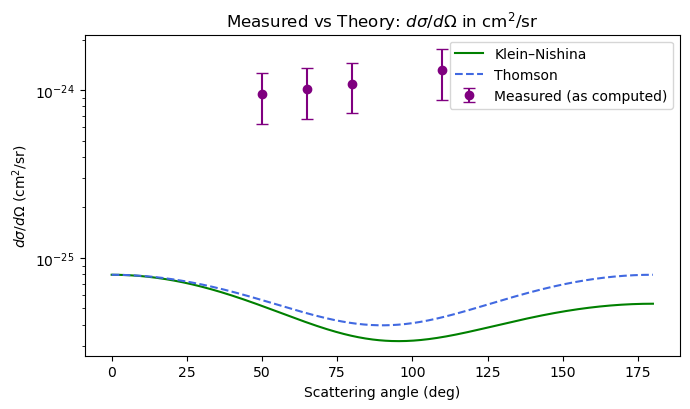

In [168]:
areas = {50: area50, 65: area65, 80: area80, 110: area110}
spec_objs = {50: deg50_spec, 65: deg65_spec, 80: deg80_spec, 110: deg110_spec}

# deometry
A_det_mm2 = 9.0
A_det_cm2 = A_det_mm2 / 100.0        
dtd_mm = 40.0                       
r_cm = dtd_mm / 10.0                
DeltaOmega = A_det_cm2 / (r_cm**2)   

dst_mm = 225.0                     

# Al scatterer
N_A = 6.02214076e23
density_Al = 2.7                 
A_Al = 26.9815385                 
Z_Al = 13.0

d_cm = 1.905                       
h_cm = 6.0                          
h_unc_cm = 2.0                      

vol_cm3 = np.pi * (d_cm/2.0)**2 * h_cm
mass_g = density_Al * vol_cm3
atoms = (mass_g / A_Al) * N_A
N_e = atoms * Z_Al

print(f"ΔΩ = {DeltaOmega:.4e} sr   (A_det={A_det_cm2:.4f} cm^2, r={r_cm:.2f} cm)") # had to copy past vars again so not uglyyyy
print(f"N_e = {N_e:.4e} electrons   (Al rod, h = {h_cm} ± {h_unc_cm} cm)\n")

rows = []
for theta_deg in sorted(areas.keys()):
    area_counts = float(areas[theta_deg])
    live_time = float(spec_objs[theta_deg].header.get("LIVE_TIME"))

    # measured peak rate and Poisson uncertainty
    R_cps = area_counts / live_time
    R_unc = np.sqrt(area_counts) / live_time

    # detector-normalized rate (counts/s/mm^2)
    det_per_mm2 = R_cps / A_det_mm2
    det_unc_per_mm2 = R_unc / A_det_mm2
    dsd_mm = geometry_dsd(dst_mm, dtd_mm, theta_deg)
    source_per_mm2 = det_per_mm2 * (dsd_mm / dst_mm)**2
    source_unc_per_mm2 = det_unc_per_mm2 * (dsd_mm / dst_mm)**2

    # flux at target in photons/s/cm^2
    phi_per_cm2_s = source_per_mm2 * 100.0
    phi_unc_per_cm2_s = source_unc_per_mm2 * 100.0

    # measured
    dsdo_cm2_per_sr = R_cps / (phi_per_cm2_s * N_e * DeltaOmega)

    # unc prop
    rel_var = 0.0
    if R_cps > 0:
        rel_var += (R_unc / R_cps)**2
    if phi_per_cm2_s > 0:
        rel_var += (phi_unc_per_cm2_s / phi_per_cm2_s)**2
    rel_var += (h_unc_cm / h_cm)**2

    dsdo_unc_cm2_per_sr = dsdo_cm2_per_sr * np.sqrt(rel_var)

    rows.append((theta_deg, dsdo_cm2_per_sr, dsdo_unc_cm2_per_sr, R_cps, R_unc, phi_per_cm2_s))

print(r"theta | dσ/dΩ (cm^2/sr) ± unc | R(cps) ± unc | phi (ph/s/cm^2)") # had to copy paste vars
print("-"*92)
for th, ds, dsu, Rv, Ru, phi in rows:
    print(f"{th:5.0f} | {ds: .6e} ± {dsu:.2e} | {Rv: .6f} ± {Ru:.6f} | {phi: .4e}")

# theoretical kn & thomson
E0_keV = 59.54
mec2_keV = 511.0
r0_m = 2.8179403262e-15
r0_cm = r0_m * 100.0

def klein_nishina_cm2(theta_deg):
    th = np.deg2rad(theta_deg)
    f = 1 + np.cos(th)**2
    g = (E0_keV/mec2_keV) * (1 - np.cos(th))
    return (r0_cm**2/2.0) * (1/(1+g)**2) * (f + (g**2/(1+g))) # cm^2/sr

def thomson_cm2(theta_deg):
    th = np.deg2rad(theta_deg)
    return (r0_cm**2/2.0) * (1 + np.cos(th)**2) # cm^2/sr

theta_full = np.linspace(0, 180, 600)
KN_full = np.array([klein_nishina_cm2(t) for t in theta_full])
TH_full = np.array([thomson_cm2(t) for t in theta_full])

theta_meas = np.array([r[0] for r in rows], float)
dsdo_meas = np.array([r[1] for r in rows], float)
dsdo_meas_unc = np.array([r[2] for r in rows], float)

KN_pts = np.array([klein_nishina_cm2(t) for t in theta_meas])
TH_pts = np.array([thomson_cm2(t) for t in theta_meas])

# plt
plt.figure(figsize=(7,4.2))
plt.plot(theta_full, KN_full, label="Klein–Nishina", color="green")
plt.plot(theta_full, TH_full, label="Thomson", color="royalblue", linestyle="--")
plt.errorbar(theta_meas, dsdo_meas, yerr=dsdo_meas_unc,
             fmt="o", color="purple", label="Measured (as computed)", capsize=4)

plt.yscale("log")
plt.xlabel("Scattering angle (deg)")
plt.ylabel(r"$d\sigma/d\Omega$ (cm$^2$/sr)")
plt.title(r"Measured vs Theory: $d\sigma/d\Omega$ in cm$^2$/sr")
plt.legend()
plt.tight_layout()
plt.show()

In [169]:
# chi^2 to see if hypothesis that the x-ray energy and scattering angle are described by the Compton relationship

peak_energies = np.array([56.779, 55.663, 54.415, 51.452])
peak_energy_unc = [0.076, 0.045, 0.047, 0.035]

angles_deg = np.array([50, 65, 80, 110])
angles_rad = np.deg2rad(angles_deg)

E0 = 59.54
mec2 = 511.0

E_theory = E0 / (1 + (E0/mec2)*(1 - np.cos(angles_rad)))

# chi-squared
chi2_val = np.sum(((peak_energies - E_theory)/peak_energy_unc)**2)

# degrees of freedom
dof = len(peak_energies) # no fitted parameters here

chi2_reduced = chi2_val / dof

# p-value
p_value = 1 - chi2.cdf(chi2_val, dof)

print("Chi-squared =", chi2_val)
print("Degrees of freedom =", dof)
print("Reduced chi-squared =", chi2_reduced)
print("p-value =", p_value)

Chi-squared = 38.86332132348843
Degrees of freedom = 4
Reduced chi-squared = 9.715830330872107
p-value = 7.43431001204442e-08


#### KN from Compton Continuum

Shape-only scale factor A = 1.8573336960261586e-23


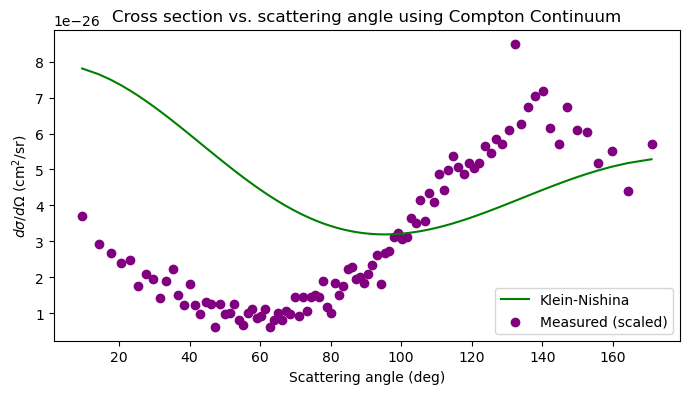

In [ ]:
cc_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021726_wkndrun_comptoncont_Gain5.26_2048ch.mca"
)

counts = np.asarray(cc_spec.counts, float)
live_time = float(cc_spec.header.get("LIVE_TIME"))

# calibration (cal)
(ch1, E1), (ch2, E2) = cc_spec.calibration_points[:2]
m = (E2 - E1) / (ch2 - ch1)
b = E1 - m * ch1

channels = np.arange(counts.size)
E_keV = m * channels + b

# region of interest
E0 = 59.54
Emin = 45.0
Emax = E0

mask = (E_keV >= Emin) & (E_keV <= Emax)
E_dep = E_keV[mask]
N_bin = counts[mask]

dE = m # from cal
dN_dE = N_bin / (live_time * dE)

# convert
mec2 = 511.0 # for electron
alpha = E0 / mec2 

# convert from energy to cos theta which we can get theta from
Eprime = E_dep
cos_theta = 1 - ( (E0 / Eprime) - 1 ) / alpha # compton formula (i derived this so p sure it is correct)

# remove unphysical numerical values
valid = (cos_theta >= -1) & (cos_theta <= 1)
Eprime = Eprime[valid]
dN_dE = dN_dE[valid]
cos_theta = cos_theta[valid]

theta = np.arccos(cos_theta)

# KN in cm^2/sr

r0_cm = 2.8179403262e-15 * 100.0

# from manual
def KN_cm2(theta_rad):
    f = 1 + np.cos(theta_rad)**2
    g = alpha * (1 - np.cos(theta_rad))
    return (r0_cm**2 / 2.0) * (1/(1+g)**2) * (f + (g**2/(1+g)))

KN_vals = KN_cm2(theta)

# fit scale so measured matches KN shape
A = np.sum(dN_dE * KN_vals) / np.sum(dN_dE**2)
dsdo_meas_scaled = A * dN_dE

print("Shape-only scale factor A =", A)

# plt
theta_deg = np.degrees(theta)

plt.figure(figsize=(7,4.2))
plt.plot(theta_deg, KN_vals, label="Klein-Nishina", color="green")
plt.scatter(theta_deg, dsdo_meas_scaled,
            color="purple", label="Measured (scaled)")
plt.xlabel("Scattering angle (deg)")
plt.ylabel(r"$d\sigma/d\Omega$ (cm$^2$/sr)")
plt.title("Cross section vs. scattering angle using Compton Continuum")
plt.legend()
plt.tight_layout()
plt.show()

channels: 2048
live time: 332374.133
start time: 02/13/2026 16:41:38
n rois: 1
cal points: [(125.51, 13.5), (527.84, 59.54)]
Energy calibration: E = 0.114433*ch + -0.862539 keV
Scale factor A = 1.857334e-23  [cm^2/sr per (count/s/keV)]  (shape-only)


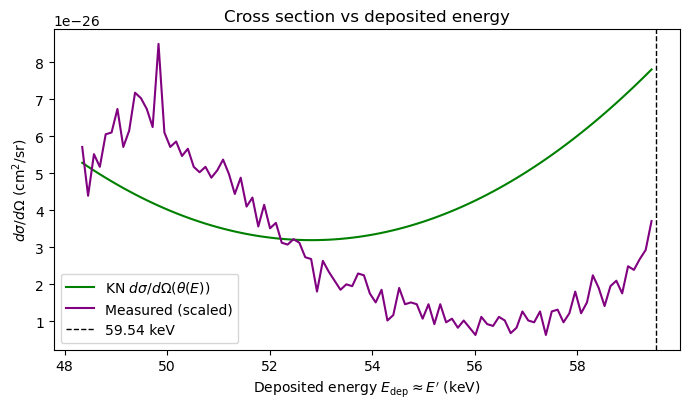

In [62]:
cc_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021726_wkndrun_comptoncont_Gain5.26_2048ch.mca"
)

counts = np.asarray(cc_spec.counts, float)
live_time = float(cc_spec.header.get("LIVE_TIME"))

print("channels:", counts.size)
print("live time:", live_time)
print("start time:", cc_spec.header.get("START_TIME"))
print("n rois:", len(cc_spec.rois))
print("cal points:", cc_spec.calibration_points[:5])

# energy calibration
(ch1, E1), (ch2, E2) = cc_spec.calibration_points[:2]
m = (E2 - E1) / (ch2 - ch1)     
b = E1 - m * ch1                
print(f"Energy calibration: E = {m:.6f}*ch + {b:.6f} keV")

channels = np.arange(counts.size)
E_keV = m * channels + b

# energy window
E0 = 59.54
Emin = 45.0  
Emax = E0

mask = (E_keV >= Emin) & (E_keV <= Emax)
E_dep = E_keV[mask]             
N_bin = counts[mask]

dE = m
dN_dE = N_bin / (live_time * dE)

# map energy
mec2 = 511.0
alpha = E0 / mec2

Eprime = E_dep.copy()
cos_theta = 1.0 - ((E0 / Eprime) - 1.0) / alpha

valid = np.isfinite(cos_theta) & (cos_theta >= -1.0) & (cos_theta <= 1.0) & (Eprime > 0)
Eprime = Eprime[valid]
dN_dE = dN_dE[valid]
cos_theta = cos_theta[valid]
theta = np.arccos(cos_theta)  

order = np.argsort(Eprime)
Eprime = Eprime[order]
theta = theta[order]
dN_dE = dN_dE[order]

# theory
r0_m = 2.8179403262e-15
r0_cm = r0_m * 100.0

def KN_cm2_per_sr(theta_rad):
    f = 1.0 + np.cos(theta_rad)**2
    g = alpha * (1.0 - np.cos(theta_rad))
    return (r0_cm**2 / 2.0) * (1.0/(1.0+g)**2) * (f + (g**2/(1.0+g)))

KN_E = KN_cm2_per_sr(theta)

A = np.sum(dN_dE * KN_E) / np.sum(dN_dE**2)
dsdo_meas_E = A * dN_dE

print(f"Scale factor A = {A:.6e}  [cm^2/sr per (count/s/keV)]  (shape-only)")

# plt
plt.figure(figsize=(7,4.2))
plt.plot(Eprime, KN_E, color="green", label=r"KN $d\sigma/d\Omega(\theta(E))$")
plt.plot(Eprime, dsdo_meas_E, color="purple", label=r"Measured (scaled)")

plt.axvline(E0, linestyle="--", color="k", linewidth=1, label="59.54 keV")
plt.xlabel(r"Deposited energy $E_{\rm dep}\approx E'$ (keV)")
plt.ylabel(r"$d\sigma/d\Omega$ (cm$^2$/sr)")
plt.title(r"Cross section vs deposited energy")
plt.tight_layout()
plt.legend()
plt.show()

## Background (no source)

In [63]:
# databk_spec
bk_spec = read_amptek_mca(
    r"c:\Users\kaela\Downloads\Phyiscs 111B\COM_Data\021726_labhours_bkgrnd_Gain5.26_2048ch.mca"
)
print("channels:", bk_spec.counts.size)
print("live time:", bk_spec.header.get("LIVE_TIME"))
print("start time:", bk_spec.header.get("START_TIME"))
print("n rois:", len(bk_spec.rois))
print("cal points:", bk_spec.calibration_points[:5])

channels: 2048
live time: 951.508213
start time: 02/17/2026 13:50:02
n rois: 3
cal points: [(125.51, 13.5), (527.84, 59.54)]


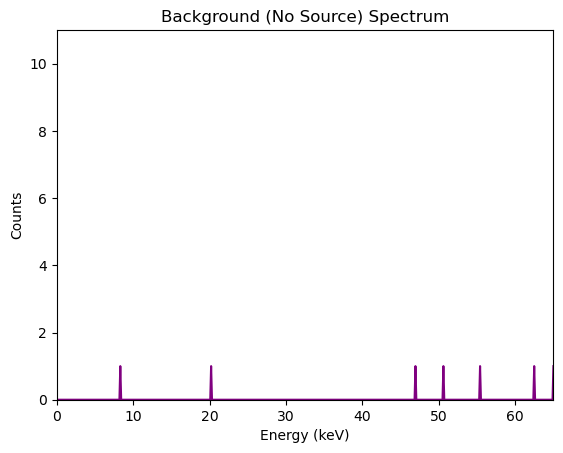

In [64]:
plt.figure()
plt.plot(energy_axis, bk_spec.counts, color ='purple')
plt.xlabel("Energy (keV)")  
plt.ylabel("Counts")
plt.title("Background (No Source) Spectrum")
plt.xlim(0, 65)
plt.ylim(0, np.max(bk_spec.counts) + 10)
plt.show()

## Gaussian fits (eventual electron mass)

In [65]:
def gauss_const(x, A, mu, sigma, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + C

In [66]:
def gauss_fit(fit_lo, fit_hi, counts, name): 
    mask = (E >= fit_lo) & (E <= fit_hi)
    x = E[mask]
    y = counts[mask]

    # initial guess
    C0 = np.median(y[:max(3, len(y)//5)]) # baseline guess from left side of window
    A0 = np.max(y) - C0
    mu0 = x[np.argmax(y)]
    sigma0 = 0.6                                

    p0 = [A0, mu0, sigma0, C0]

    # constrain sigma > 0
    bounds = ([0, fit_lo, 1e-6, -np.inf],
            [np.inf, fit_hi, np.inf, np.inf])

    popt, pcov = curve_fit(gauss_const, x, y, p0=p0, bounds=bounds)
    A, mu, sigma, C = popt
    perr = np.sqrt(np.diag(pcov))

    fwhm = 2.354820045 * sigma
    fwhm_err = 2.354820045 * perr[2]

    print(f"Gaussian fit:")
    print(f"  A     = {A:.2f} ± {perr[0]:.2f}")
    print(f"  mu    = {mu:.3f} ± {perr[1]:.3f} keV")
    print(f"  sigma = {sigma:.3f} ± {perr[2]:.3f} keV")
    print(f"  FWHM  = {fwhm:.3f} ± {fwhm_err:.3f} keV")
    print(f"  C     = {C:.2f} ± {perr[3]:.2f}")


    plt.figure()
    plt.plot(E, counts, color='olive', label="Data")
    plt.xlabel("Energy (keV)")
    plt.ylabel("Counts")
    plt.title(f"Background Subtracted {name} Degree Scattering Angle Spectrum")
    plt.xlim(0, 70)
    plt.ylim(0, np.max(counts) + 30)

    # overlay fit only in the fit window
    xf = np.linspace(fit_lo, fit_hi, 600)
    plt.plot(xf, gauss_const(xf, *popt), color='crimson', lw=2,
            label=f"Gaussian fit: μ={mu:.2f} keV, σ={sigma:.2f} keV")


    plt.legend()
    plt.show()

#### 50 degree

Gaussian fit:
  A     = 31.02 ± 1.42
  mu    = 56.779 ± 0.076 keV
  sigma = 1.536 ± 0.090 keV
  FWHM  = 3.616 ± 0.212 keV
  C     = -0.05 ± 0.69


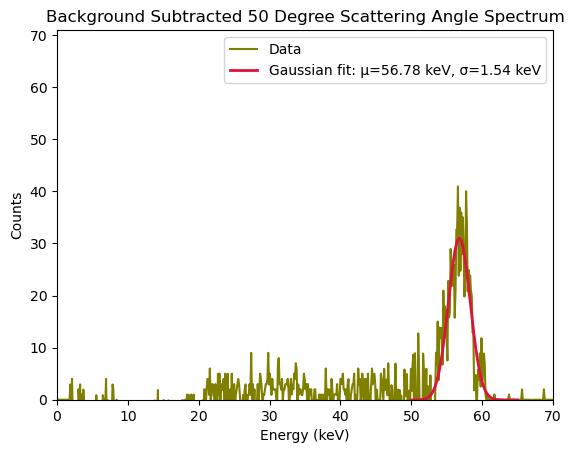

In [67]:
gauss_fit(50, 65, counts_50, 50)

#### 65 degree

Gaussian fit:
  A     = 311.61 ± 7.45
  mu    = 55.656 ± 0.042 keV
  sigma = 1.562 ± 0.045 keV
  FWHM  = 3.678 ± 0.107 keV
  C     = 14.46 ± 2.41


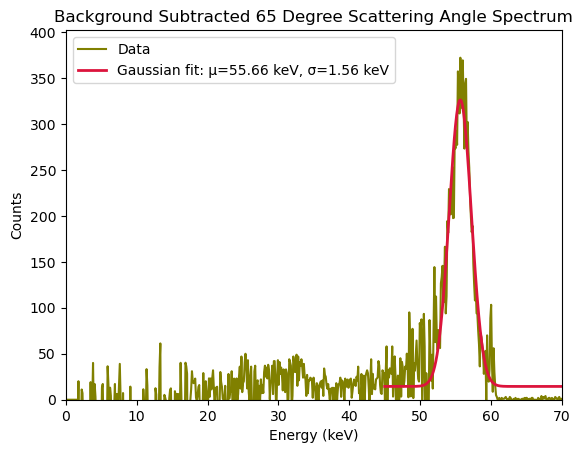

In [68]:
gauss_fit(45, 70, counts_65, 65)

#### 80 degree

Gaussian fit:
  A     = 259.93 ± 8.54
  mu    = 54.415 ± 0.047 keV
  sigma = 1.290 ± 0.053 keV
  FWHM  = 3.037 ± 0.124 keV
  C     = -4.42 ± 3.52


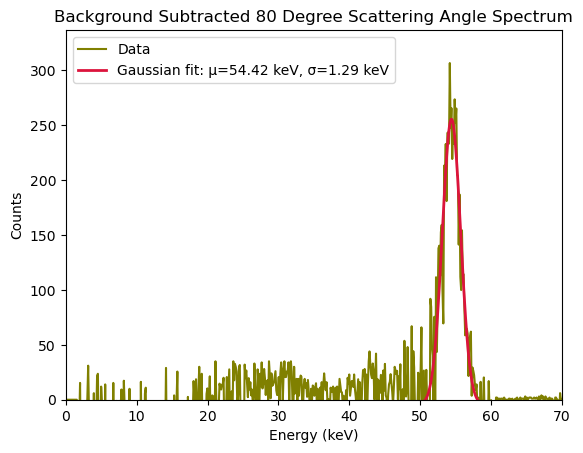

In [69]:
gauss_fit(50, 65, counts_80, 80)

#### 95 degree

In [ ]:
gauss_fit(50, 65, counts_95, 95)

#### 110 degree

Gaussian fit:
  A     = 284.43 ± 6.30
  mu    = 51.452 ± 0.035 keV
  sigma = 1.422 ± 0.038 keV
  FWHM  = 3.348 ± 0.089 keV
  C     = 21.44 ± 1.91


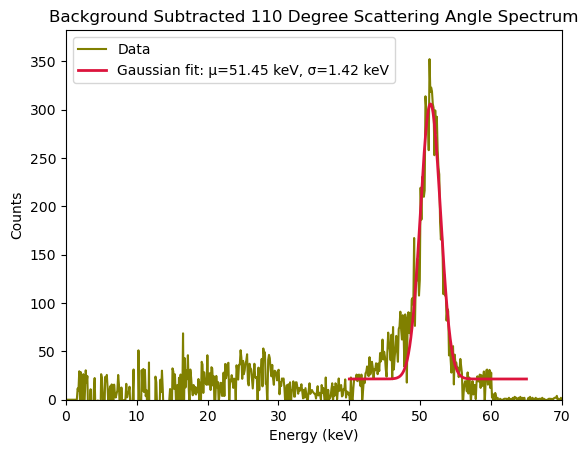

In [71]:
gauss_fit(40, 65, counts_110, 110)

#### Peak energies vs scattering angle

In [72]:
peak_energies = [56.779, 55.663, 54.415, 51.452] # fit gaussian for peak energy + uncertainty on mass
scattering_angle_deg = [50, 65, 80, 110]

peak_energy_unc = [0.076, 0.045, 0.047, 0.035]

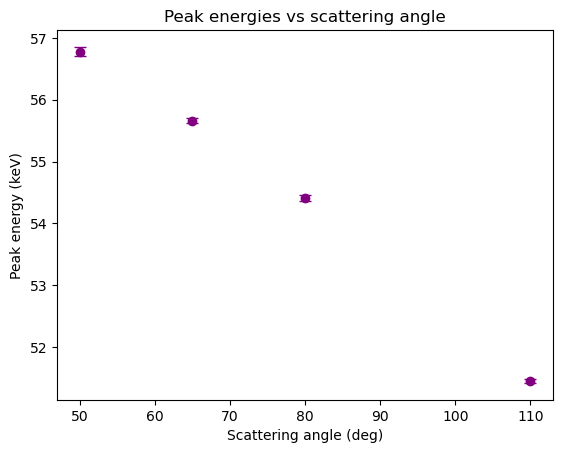

In [73]:
plt.figure()
plt.errorbar(scattering_angle_deg, peak_energies, yerr=peak_energy_unc,
             fmt='o', color="purple", capsize=4)
plt.title('Peak energies vs scattering angle')
plt.xlabel('Scattering angle (deg)')
plt.ylabel('Peak energy (keV)')
plt.show()

In [74]:
peak_energies = np.array(peak_energies)
theta = np.deg2rad(scattering_angle_deg)

x = 1 - np.cos(theta)
y = 1 / peak_energies

y_unc = peak_energy_unc / (peak_energies**2)

In [75]:
w = 1 / y_unc 

fit, cov = np.polyfit(x, y, deg=1, w=w, cov=True)
a, b = fit
a_unc = np.sqrt(cov[0, 0])
b_unc = np.sqrt(cov[1, 1])

print(f"Slope a = {a:.6e} ± {a_unc:.2e}")
print(f"Intercept b = {b:.6e} ± {b_unc:.2e}")

energy_keV = 1 / a

# propagate uncertainty 
energy_keV_unc = (a_unc / (a**2))

mass_MeV = energy_keV / 1000.0
mass_MeV_unc = energy_keV_unc / 1000.0

print(f"m_e c^2 = {energy_keV:.2f} ± {energy_keV_unc:.2f} keV")
print(f"Electron mass = {mass_MeV:.6f} ± {mass_MeV_unc:.6f} MeV")

Slope a = 1.899094e-03 ± 7.48e-05
Intercept b = 1.686752e-02 ± 7.15e-05
m_e c^2 = 526.57 ± 20.74 keV
Electron mass = 0.526567 ± 0.020736 MeV


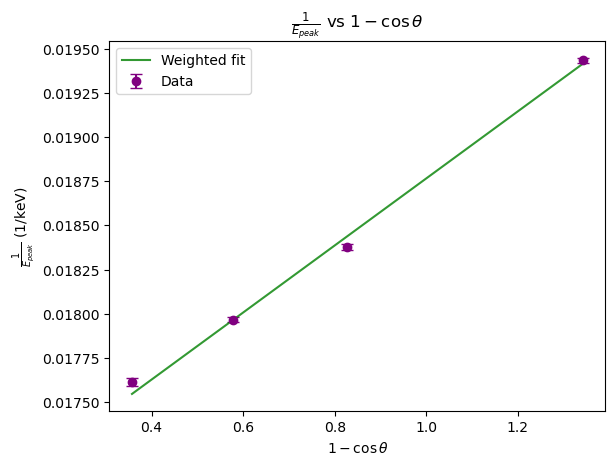

In [76]:
plt.figure()
plt.errorbar(x, y, yerr=y_unc, fmt='o', color="purple", capsize=4, label="Data")

xf = np.linspace(np.min(x), np.max(x), 300)
yf = a*xf + b
plt.plot(xf, yf, color='green', alpha=0.8, label="Weighted fit")

plt.title(r'$\frac{1}{E_{peak}}$ vs $1-\cos \theta$')
plt.xlabel(r'$1-\cos \theta$')
plt.ylabel(r'$\frac{1}{E_{peak}}$ (1/keV)')
plt.legend()
plt.show()